# Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("monk_skin_tone_classification.csv")
data = data[(data["Gender Presentation"] != "Indeterminiate") & (data["Monk Label"] != "Indeterminiate")]
data["Monk Label"] = data["Monk Label"].astype(int)

In [3]:
de = data[data["Image Model"] == "DALL-E 3"]
mj = data[data["Image Model"] == "MidJourney 6.1"]
sd = data[data["Image Model"] == "Stable Diffusion 3.5 Model Suite Large Turbo"]

In [4]:
sns.set_palette("tab10")

## Labels & Values

In [5]:
# "Image Model"
model_order = ["DALL-E 3", "MidJourney 6.1", "Stable Diffusion 3.5 Model Suite Large Turbo"]
models = ["DALL-E 3", "MidJourney 6.1", "Stable Diffusion 3.5"]

cDE = "orangered"
cMJ = "darkcyan"
cSD = "mediumpurple"

cModels = {
    "DALL-E 3" : cDE,
    "MidJourney 6.1" : cMJ,
    "Stable Diffusion 3.5 Model Suite Large Turbo" : cSD
}

In [6]:
# "Job"
job_order = ["Soldier", "Mechanic", "Medical Doctor", "Fortune 500 CEO", "Surgeon", "Sanitation Worker",
             "Doctor", "Construction Worker", "Janitor", "Entrepreneur", "Lawyer", "Teacher", "Engineer",
             "Attorney", "Software Developer"]
jobs = ["Soldier", "Mechanic", "Medical\nDoctor", "Fortune\n500 CEO", "Surgeon", "Sanitation\nWorker",
        "Doctor", "Construction\nWorker", "Janitor", "Entrepreneur", "Lawyer", "Teacher", "Engineer",
        "Attorney", "Software\nDeveloper"]

In [7]:
# "Gender Presentation"
genders = ["Masculine", "Feminine"]

cM = "darkgreen"
cF = "darkorange"

cGender = {
    "Masculine" : cM,
    "Feminine" : cF
}


In [8]:
# "Monk Label"
skin = list(range(11))

# Plots

## Gender Presentation vs. Model

In [9]:
hm_count = [[len(data[(data["Gender Presentation"] == g) & (data["Image Model"] == m)]) for g in genders] for m in model_order]
hm_prop = np.divide(hm_count, np.sum(hm_count, axis=0))

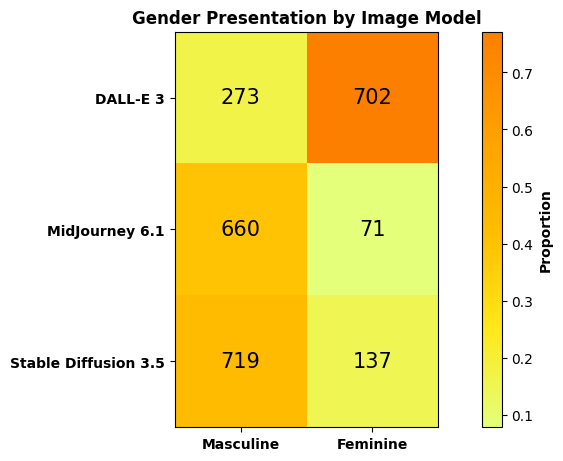

In [10]:
# figure
fig = plt.figure(figsize=(10,4.5), layout="constrained")
ax = fig.gca()

# heatmap
hm = ax.imshow(X=hm_prop, cmap="Wistia")

# annotations
[ax.text(x=i, y=j, s=f"{hm_count[j][i]}", ha="center", va="center", size=15) for i in range(2) for j in range(3)]

# labels
ax.set_title("Gender Presentation by Image Model", weight="bold")
ax.set_xticks(ticks=range(2), labels=genders, weight="bold")
ax.set_yticks(ticks=range(3), labels=models, weight="bold")

# colorbar
cb = plt.colorbar(hm)
cb.ax.set_ylabel("Proportion", weight="bold")

# save
fig.savefig("figures/gender_presentation_by_model.svg", transparent=True)

## Skin Tone vs. Model

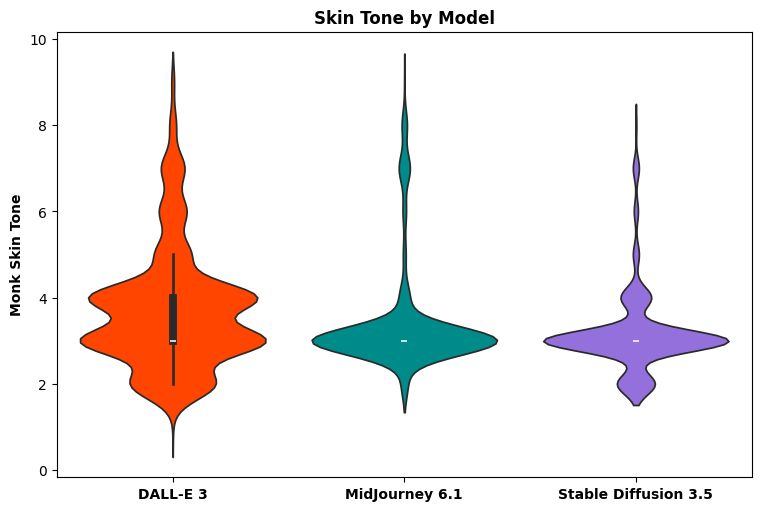

In [11]:
# figure
fig = plt.figure(figsize=(7.5,5), layout="constrained")
ax = fig.gca()

# plot
sns.violinplot(data, x="Image Model", y="Monk Label", order=model_order,
               hue="Image Model", hue_order=model_order, palette=cModels,
               saturation=1, ax=ax)

# labels
ax.set_title("Skin Tone by Model", weight="bold")
ax.set_xlabel(None)
ax.set_xticks(ticks=range(3), labels=models, weight="bold")
ax.set_ylabel("Monk Skin Tone", weight="bold")

# save
fig.savefig("figures/skin_tone_by_model.svg")

## Skin Tone & Gender Presentation vs. Model

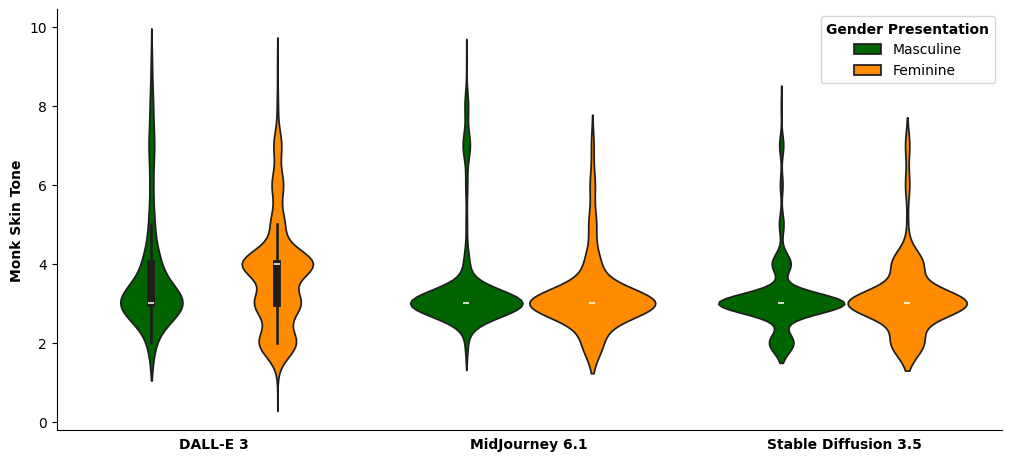

In [39]:
# figure
fig = plt.figure(figsize=(10,4.5), layout="constrained")
ax = fig.gca()

# plot
sns.violinplot(data, x="Image Model", y="Monk Label", order=model_order,
               hue="Gender Presentation", hue_order=genders, palette=cGender,
               saturation=1, ax=ax)

# labels
# ax.set_title("Skin Tone & Gender Presentation by Model", weight="bold")
ax.set_xlabel(None)
ax.set_xticks(ticks=range(3), labels=models, weight="bold")
ax.set_ylabel("Monk Skin Tone", weight="bold")
ax.legend(title="Gender Presentation", title_fontproperties={"weight":"bold"})

# axis specifications
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params("x", length=0, pad=5)

# save
fig.savefig("figures/skin_tone_gender_by_model.svg", transparent=True)

## Gender Presentation vs. Job

In [13]:
x = list(range(len(jobs)))

yDE_M = [len(de[(de["Job"] == j) & (de["Gender Presentation"] == "Masculine")])/len(de[de["Job"] == j]) for j in job_order]
yDE_F = [len(de[(de["Job"] == j) & (de["Gender Presentation"] == "Feminine")])/len(de[de["Job"] == j]) for j in job_order]

yMJ_M = [len(mj[(mj["Job"] == j) & (mj["Gender Presentation"] == "Masculine")])/len(mj[mj["Job"] == j]) for j in job_order]
yMJ_F = [len(mj[(mj["Job"] == j) & (mj["Gender Presentation"] == "Feminine")])/len(mj[mj["Job"] == j]) for j in job_order]

ySD_M = [len(sd[(sd["Job"] == j) & (sd["Gender Presentation"] == "Masculine")])/len(sd[sd["Job"] == j]) for j in job_order]
ySD_F = [len(sd[(sd["Job"] == j) & (sd["Gender Presentation"] == "Feminine")])/len(sd[sd["Job"] == j]) for j in job_order]

In [14]:
def plot_gender_job(yM:list[float], yF:list[float], title:str, ax:plt.Axes, showXTicks:bool=True, showYLabel:bool=True) -> list:
    
    # plot
    bM = ax.bar(x=x, height=yM, color=cM, label="Masculine")
    bF = ax.bar(x=x, height=yF, bottom=yM, color=cF, label="Feminine")

    # labels
    ax.set_title(title, weight="bold")

    if showXTicks:
      ax.set_xticks(ticks=x, labels=jobs, weight="bold")
    else:
       ax.set_xticks(ticks=[])
  
    if showYLabel:
      ax.set_ylabel("Proportion", weight="bold")

    ax.set_xlim(left=-0.65, right=14.65)

    return [bM, bF]

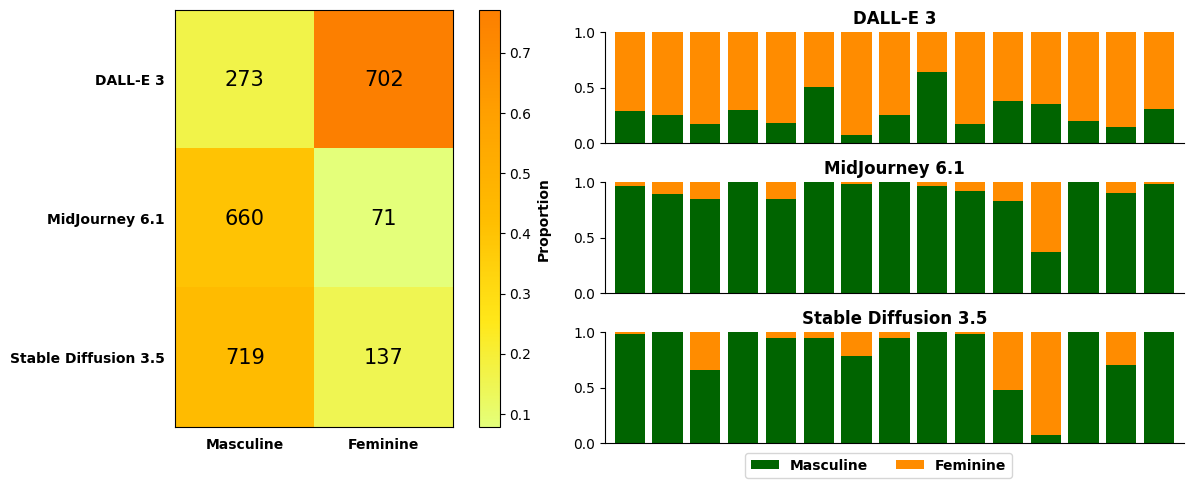

In [45]:
# figure

fig = plt.figure(figsize=(12.5,4.5), layout="constrained")
sub = fig.subfigures(ncols=2)

# HEATMAP
axHM = sub[0].subplots()

# heatmap
hm = axHM.imshow(X=hm_prop, cmap="Wistia")

# annotations
[axHM.text(x=i, y=j, s=f"{hm_count[j][i]}", ha="center", va="center", size=15) for i in range(2) for j in range(3)]

# labels
# axHM.set_title("Gender Presentation by Image Model", weight="bold")
axHM.set_xticks(ticks=range(2), labels=genders, weight="bold")
axHM.set_yticks(ticks=range(3), labels=models, weight="bold")

# axis specifications
axHM.tick_params("both", length=0, pad=7.5)

# colorbar
cb = plt.colorbar(hm)
cb.ax.set_ylabel("Proportion", weight="bold")

# BY JOB
ax = sub[1].subplots(nrows=3, sharey=True)

# bar plots
bM, bF = plot_gender_job(yDE_M, yDE_F, "DALL-E 3", ax[0], showXTicks=False, showYLabel=False)
plot_gender_job(yMJ_M, yMJ_F, "MidJourney 6.1", ax[1], showXTicks=False, showYLabel=False)
plot_gender_job(ySD_M, ySD_F, "Stable Diffusion 3.5", ax[2], showXTicks=False, showYLabel=False)

# axis specifications
[a.spines["top"].set_visible(False) for a in ax]
[a.spines["right"].set_visible(False) for a in ax]

# labels
# sub[1].suptitle("Gender Presentation by Job", weight="bold", size=14)
sub[1].legend(handles=[bM, bF], ncols=2, prop={"weight" : "bold"},
              # title="Gender Presentation", title_fontproperties={"weight":"bold"},
              loc=8, bbox_to_anchor=(0.5,-0.065))

# save
fig.savefig("figures/gender_presentation_all.svg", transparent=True, bbox_inches="tight")

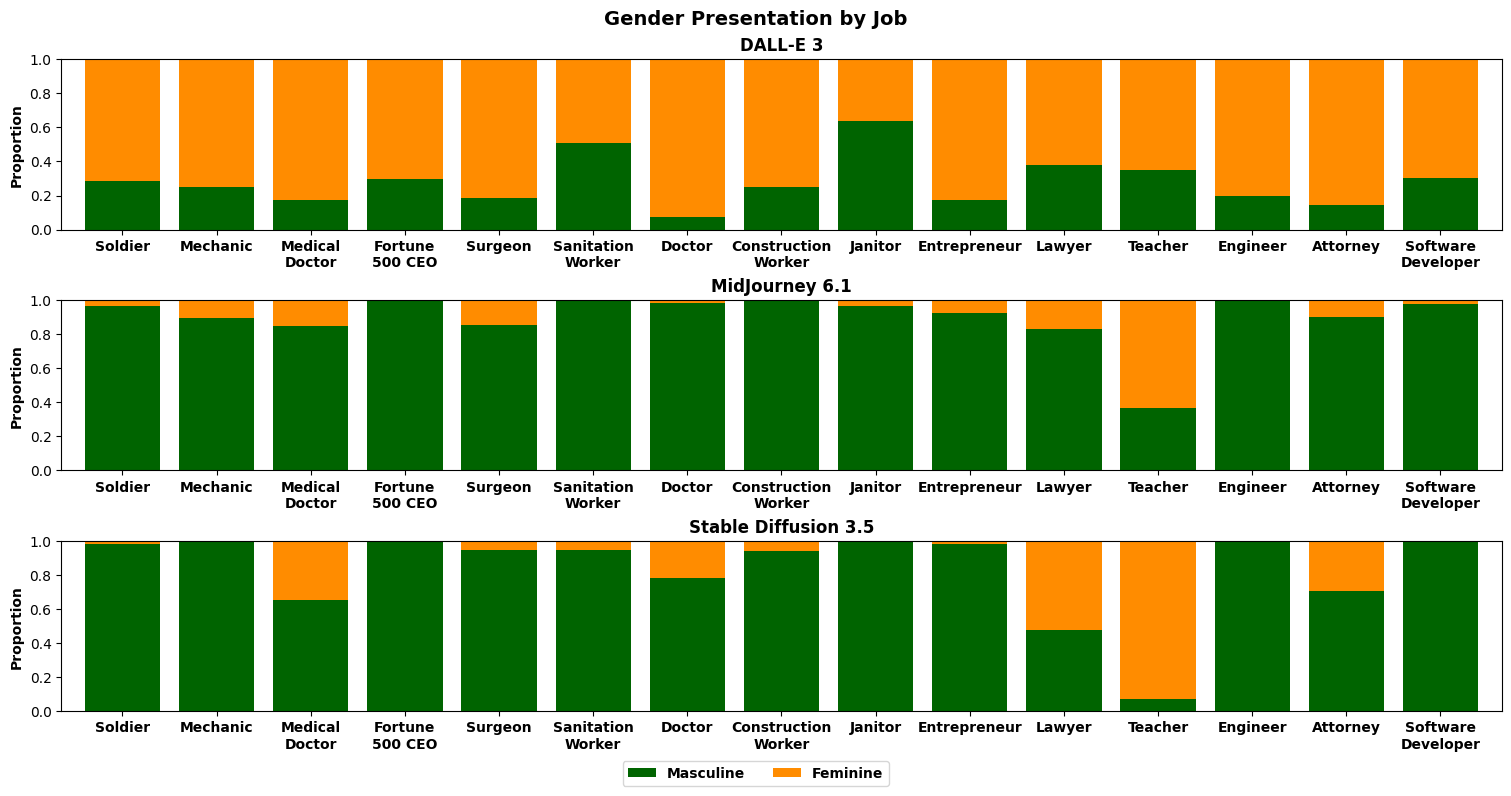

In [42]:
# figure
fig,ax = plt.subplots(nrows=3, sharey=True, figsize=(15,7.5), layout="constrained")

# plot
bM, bF = plot_gender_job(yDE_M, yDE_F, "DALL-E 3", ax[0])
plot_gender_job(yMJ_M, yMJ_F, "MidJourney 6.1", ax[1])
plot_gender_job(ySD_M, ySD_F, "Stable Diffusion 3.5", ax[2])

# labels
fig.suptitle("Gender Presentation by Job", weight="bold", size=14)
fig.legend(handles=[bM, bF], ncols=2, prop={"weight" : "bold"}, # title="Gender Presentation", title_fontproperties={"weight":"bold"},
           loc=8, bbox_to_anchor=(0.5,-0.05))

# save
fig.savefig("figures/gender_presentation_v_job_all.svg", bbox_inches="tight")

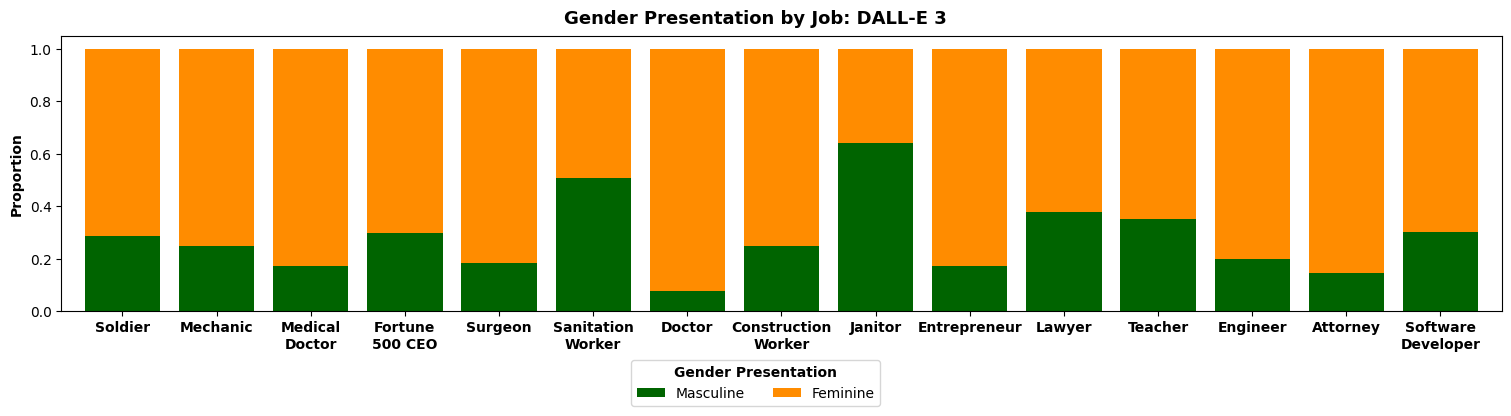

In [17]:
# DALL-E 3
fig = plt.figure(figsize=(15, 3.5), layout="constrained")
ax = plt.gca()

bM, bF = plot_gender_job(yDE_M, yDE_F, None, ax)

fig.suptitle("Gender Presentation by Job: DALL-E 3", weight="bold", size=13)
fig.legend(handles=[bM, bF], ncols=2, title="Gender Presentation", title_fontproperties={"weight":"bold"},
           loc=8, bbox_to_anchor=(0.5,-0.165))

# save
fig.savefig("figures/gender_presentation_v_job_dalle3.svg", transparent=True, bbox_inches="tight")

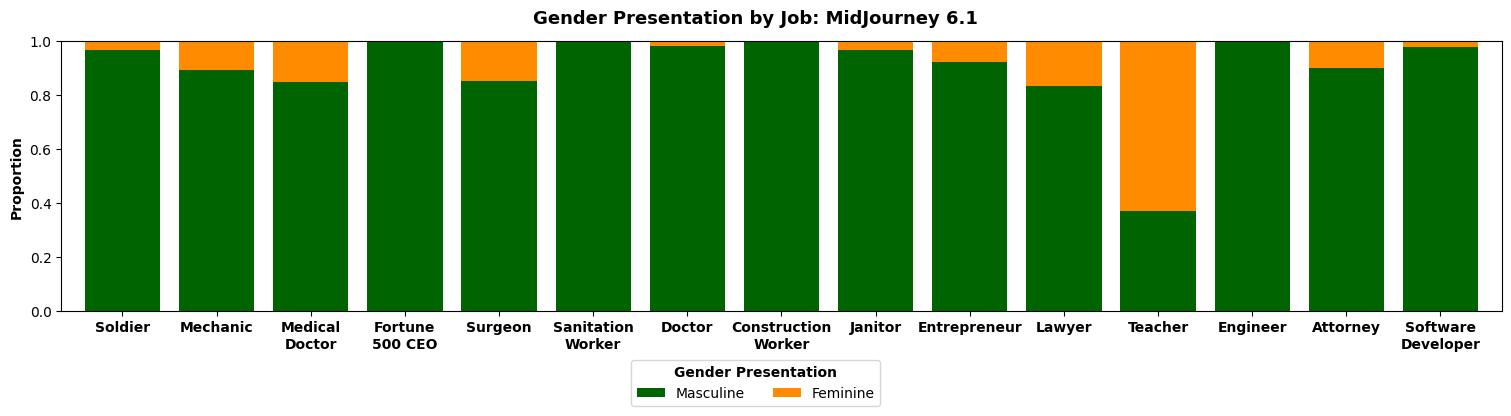

In [18]:
# MidJourney 6.1
fig = plt.figure(figsize=(15, 3.5), layout="constrained")
ax = plt.gca()

bM, bF = plot_gender_job(yMJ_M, yMJ_F, None, ax)

fig.suptitle("Gender Presentation by Job: MidJourney 6.1", weight="bold", size=13)
fig.legend(handles=[bM, bF], ncols=2, title="Gender Presentation", title_fontproperties={"weight":"bold"},
           loc=8, bbox_to_anchor=(0.5,-0.165))

# save
fig.savefig("figures/gender_presentation_v_job_midjourney.svg", transparent=True, bbox_inches="tight")

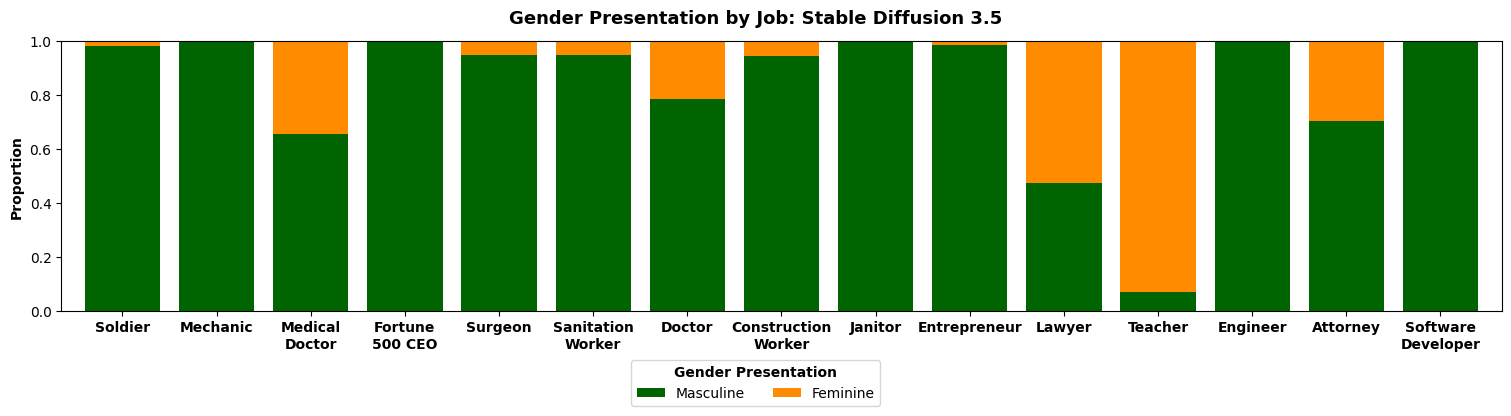

In [19]:
# Stable Diffusion 3.5
fig = plt.figure(figsize=(15, 3.5), layout="constrained")
ax = plt.gca()

bM, bF = plot_gender_job(ySD_M, ySD_F, None, ax)

fig.suptitle("Gender Presentation by Job: Stable Diffusion 3.5", weight="bold", size=13)
fig.legend(handles=[bM, bF], ncols=2, title="Gender Presentation", title_fontproperties={"weight":"bold"},
           loc=8, bbox_to_anchor=(0.5,-0.165))

# save
fig.savefig("figures/gender_presentation_v_job_stable_diffusion.svg", transparent=True, bbox_inches="tight")

## Skin Tone vs. Job

In [20]:
def plot_monk_job(df:pd.DataFrame, c:str, ax:plt.Axes, showXTicks:bool=True, showYLabel:bool=True, xTickSize:str|float=None):
  
  # violin plot
  sns.violinplot(df, x="Job", y="Monk Label", order=job_order, color=c, saturation=1, ax=ax)
  
  # labels
  if showXTicks:
    ax.set_xticks(ticks=range(len(jobs)), labels=jobs, weight="bold", size=xTickSize)
  else:
    ax.set_xticks(ticks=[])
  ax.set_xlabel(None)

  if showYLabel:
    ax.set_ylabel("Monk Skin Tone", weight="bold")
  else:
    ax.set_ylabel(None)

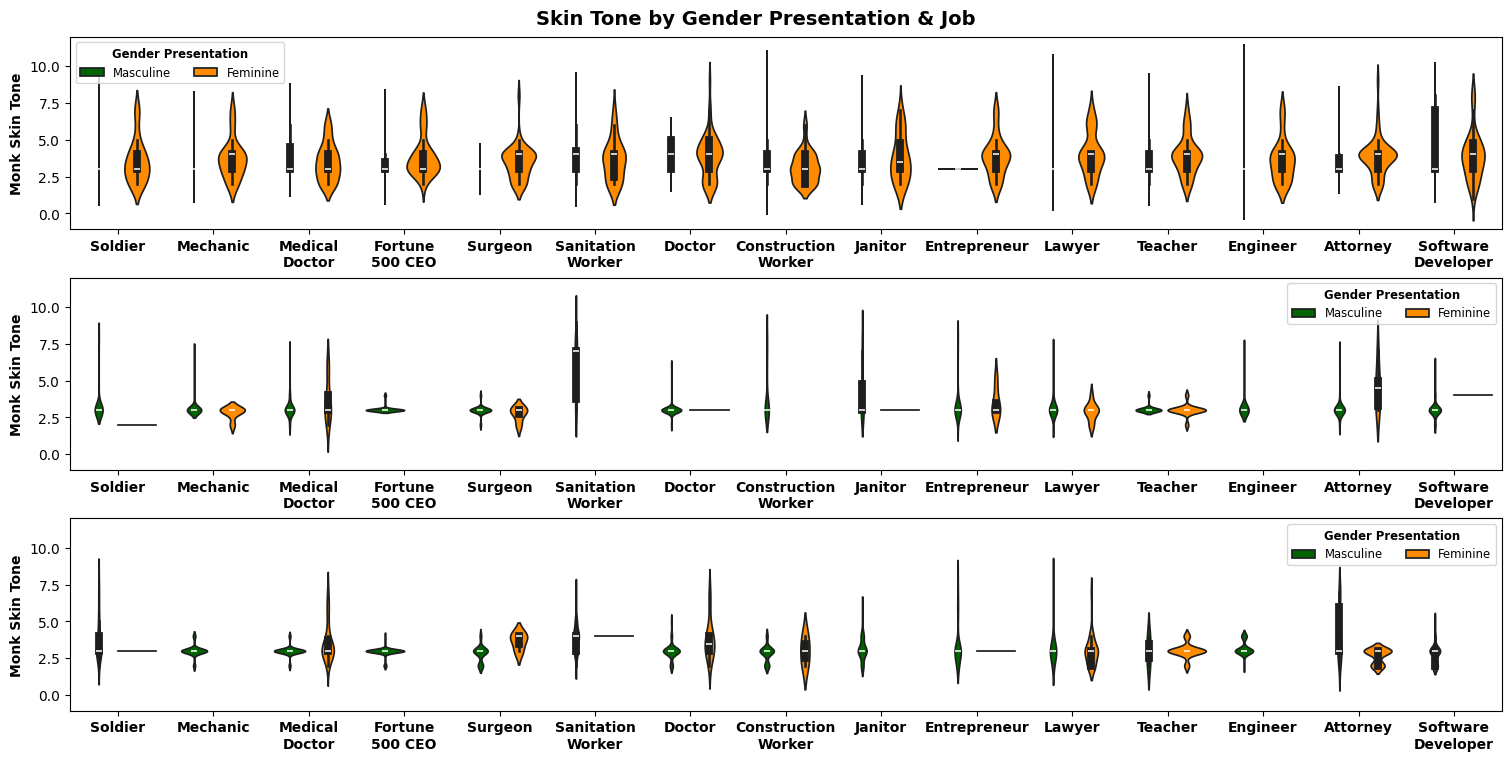

In [41]:
# ALL
fig,ax = plt.subplots(nrows=3, sharey=True, figsize=(15,7.5), layout="constrained")

# plot
for df,m,c,a,l in zip([de, mj, sd], models, [cDE, cMJ, cSD], ax, [2,1,1]):
   
   sns.violinplot(df, x="Job", y="Monk Label", order=job_order, hue="Gender Presentation", hue_order=genders, palette={"Masculine" : cM, "Feminine" : cF}, saturation=1, ax=a)

   a.set_xlabel(None)
   a.set_xticks(ticks=range(len(jobs)), labels=jobs, weight="bold")
   a.set_ylabel("Monk Skin Tone", weight="bold")

   a.legend(loc=l, ncols=2, prop={"size":"small"}, title="Gender Presentation", title_fontproperties={"weight":"bold", "size":"small"})

# labels
fig.suptitle("Skin Tone by Gender Presentation & Job", weight="bold", size=14)

# save
fig.savefig("figures/jobs_all.svg")

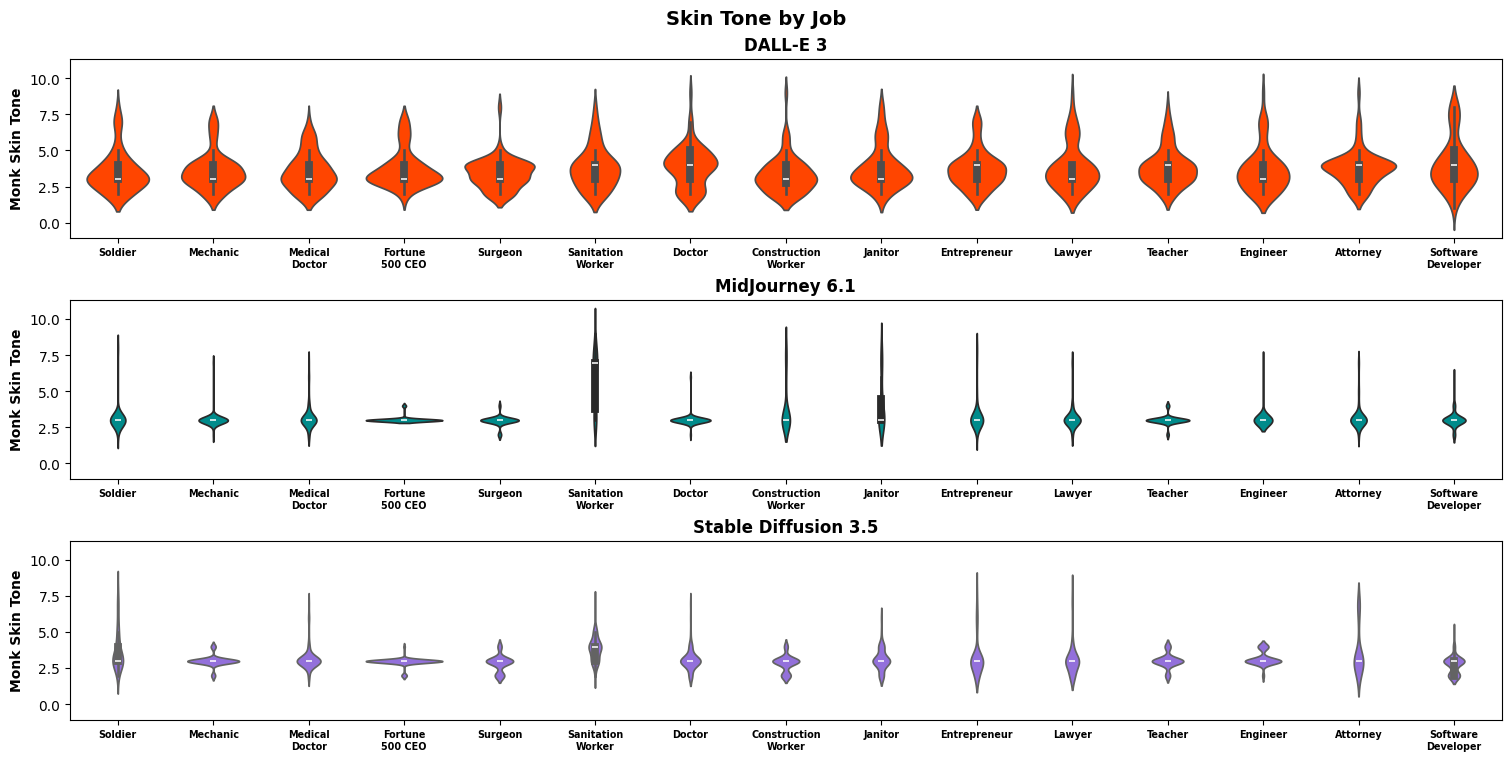

In [22]:
# ALL
fig,ax = plt.subplots(nrows=3, sharey=True, figsize=(15, 7.5), layout="constrained")

# plot
for df,m,c,a in zip([de, mj, sd], models, [cDE, cMJ, cSD], ax):
  plot_monk_job(df, c, a, showXTicks=True, showYLabel=True, xTickSize="x-small")
  a.set_title(m, weight="bold")

# labels
fig.suptitle("Skin Tone by Job", weight="bold", size=14)

# save
fig.savefig("figures/skin_tone_v_job_all.svg")

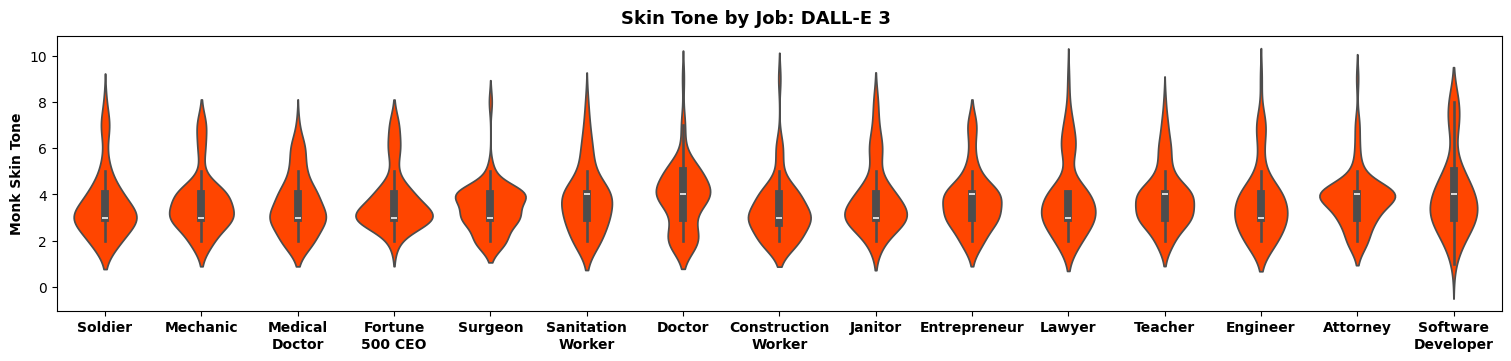

In [23]:
# DALL-E 3
fig = plt.figure(figsize=(15, 3.5), layout="constrained")
ax = plt.gca()

plot_monk_job(de, cDE, ax)

fig.suptitle("Skin Tone by Job: DALL-E 3", weight="bold", size=13)

# save
fig.savefig("figures/skin_tone_v_job_dalle3.svg", transparent=True)

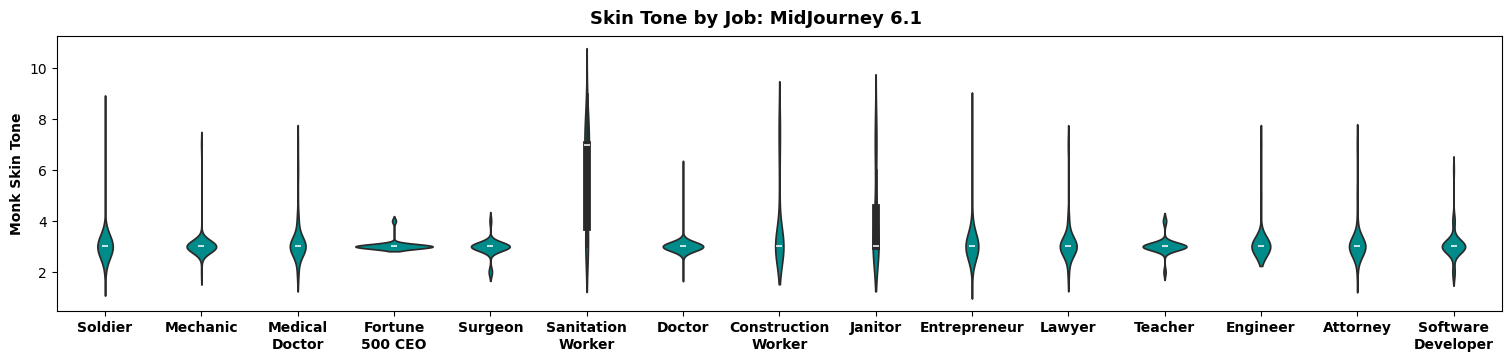

In [24]:
# MidJourney 6.1
fig = plt.figure(figsize=(15, 3.5), layout="constrained")
ax = plt.gca()

plot_monk_job(mj, cMJ, ax)

fig.suptitle("Skin Tone by Job: MidJourney 6.1", weight="bold", size=13)

# save
fig.savefig("figures/skin_tone_v_job_midjourney.svg", transparent=True)

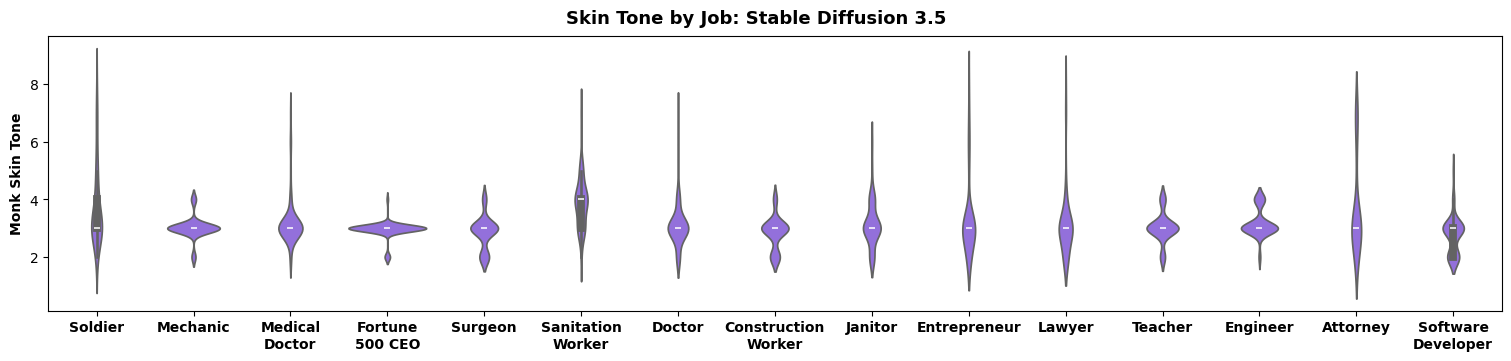

In [25]:
# Stable Diffusion 3.5
fig = plt.figure(figsize=(15, 3.5), layout="constrained")
ax = plt.gca()

plot_monk_job(sd, cSD, ax)

fig.suptitle("Skin Tone by Job: Stable Diffusion 3.5", weight="bold", size=13)

# save
fig.savefig("figures/skin_tone_v_job_stable_diffusion.svg", transparent=True)